# QCNN Trainability: Barren Plateau Analysis

This notebook reproduces the variance scaling results from the paper "Absence of Barren Plateaus in Quantum Convolutional Neural Networks" (Pesah et al.). It numerically evaluates how the variance of the cost function gradient scales with the number of qubits for both weight-shared and unshared QCNN architectures. 

The primary goal is to demonstrate that while deep, unshared parameterized quantum circuits typically suffer from exponentially vanishing gradients (Barren Plateaus), the hierarchical, translationally invariant structure of a QCNN mitigates this issue.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

## 1. Circuit Building Blocks

We define the fundamental building blocks of the QCNN:
* **The Convolutional Filter ($W$):** A highly parameterized two-qubit general unitary gate consisting of 15 rotational parameters and multiple CNOT entangling gates. 
* **The Pooling Operation:** A conditional operation that coarse-grains the quantum state, reducing the active dimension of the system by half at each layer.

In [2]:
class W(qml.operation.Operation):
    """
    A 15-parameter, two-qubit unitary block serving as the 
    convolutional filter in the QCNN architecture.
    """
    num_wires = 2
    num_params = 1 

    def __init__(self, params, wires, id=None):
        super().__init__(params, wires=wires, id=id)
        
    def label(self, decimals=None, base_label=None, cache=None):
        return "W"

    @staticmethod
    def compute_decomposition(*params, wires=None, **kwargs):
        p = params[0]
        top = wires[0]
        bot = wires[1]
        
        return [
            qml.RZ(p[0], wires=top), qml.RY(p[1], wires=top), qml.RZ(p[2], wires=top),
            qml.RZ(p[3], wires=bot), qml.RY(p[4], wires=bot), qml.RZ(p[5], wires=bot),
            qml.CNOT(wires=[bot, top]),
            qml.RZ(p[6], wires=top), qml.RY(p[7], wires=bot),
            qml.CNOT(wires=[top, bot]),
            qml.RY(p[8], wires=bot),
            qml.CNOT(wires=[bot, top]),
            qml.RZ(p[9], wires=top), qml.RY(p[10], wires=top), qml.RZ(p[11], wires=top),
            qml.RZ(p[12], wires=bot), qml.RY(p[13], wires=bot), qml.RZ(p[14], wires=bot)
        ]
    
def Pooling_ansatz1(params, wires):
    """
    A simple pooling operation using a Controlled-RZ gate.
    """
    qml.CRZ(params[0], wires=[wires[0], wires[1]])

def get_total_params(n_qubits, conv_params, pool_params, shared=False):
    """
    Calculates the total number of variational parameters required based on 
    the system size and whether weight-sharing is enforced.
    """
    curr_n = n_qubits
    total = 0
    while curr_n > 2:
        if shared:
            # Shared: parameters scale with depth O(log N)
            total += conv_params + pool_params
        else:
            # Unshared: parameters scale with the number of gates
            n_conv_gates = (curr_n - 1)
            n_pool_gates = (curr_n // 2)
            total += (n_conv_gates * conv_params) + (n_pool_gates * pool_params)
        curr_n = (curr_n // 2) + (curr_n % 2)
    return total

## 2. QCNN Architectures

We define two distinct network assembly functions:
1. **Unshared Weights:** Every convolutional and pooling block has its own independent set of parameters. This effectively acts as a highly expressive, unstructured local 2-design, which is expected to trigger a barren plateau.
2. **Shared Weights:** Parameters are shared across all spatial blocks within the same hierarchical layer, maintaining translational invariance.

In [3]:
def qcnn_layers_flat_unshared(weights_flat, n_qubits, conv_params=15, pool_params=1):
    """Constructs the QCNN with independent parameters for every gate."""
    active_wires = list(range(n_qubits))
    idx = 0
    
    while len(active_wires) > 2:
        n_active = len(active_wires)
        
        # --- Convolution Layer ---
        for i in range(0, n_active - 1, 2):
            W(weights_flat[idx : idx + conv_params], wires=[active_wires[i], active_wires[i+1]])
            idx += conv_params
            
        for i in range(1, n_active - 1, 2):
            W(weights_flat[idx : idx + conv_params], wires=[active_wires[i], active_wires[i+1]])
            idx += conv_params 

        # --- Pooling Layer ---
        new_active_wires = []
        midpoint = n_active / 2
        for i in range(0, n_active - 1, 2):
            if i < midpoint:
                # Top half: pool downwards (keep bottom wire)
                Pooling_ansatz1(weights_flat[idx : idx + pool_params], wires=[active_wires[i], active_wires[i+1]])
                kept = active_wires[i+1]
            else:
                # Bottom half: pool upwards (keep top wire)
                kept = active_wires[i]
                Pooling_ansatz1(weights_flat[idx : idx + pool_params], wires=[active_wires[i+1], active_wires[i]])
            new_active_wires.append(kept) 
            idx += pool_params
            
        if n_active % 2 != 0:
            new_active_wires.append(active_wires[-1])
            
        active_wires = new_active_wires
        
    return active_wires

def qcnn_layers_flat_shared(weights_flat, n_qubits, conv_params=15, pool_params=1):
    """Constructs the QCNN with weight-sharing enforced across spatial blocks within each layer."""
    active_wires = list(range(n_qubits))
    idx = 0
    
    while len(active_wires) > 2:
        n_active = len(active_wires)
        
        # Extract the shared weights for this specific depth level (layer)
        layer_conv_weights = weights_flat[idx : idx + conv_params]
        layer_pool_weights = weights_flat[idx + conv_params : idx + conv_params + pool_params]
        
        # --- Convolution Layer (All blocks use identical weights) ---
        for i in range(0, n_active - 1, 2):
            W(layer_conv_weights, wires=[active_wires[i], active_wires[i+1]])
            
        for i in range(1, n_active - 1, 2):
            W(layer_conv_weights, wires=[active_wires[i], active_wires[i+1]])

        # --- Pooling Layer (All blocks use identical weights) ---
        new_active_wires = []
        midpoint = n_active / 2
        for i in range(0, n_active - 1, 2):
            if i < midpoint:
                Pooling_ansatz1(layer_pool_weights, wires=[active_wires[i], active_wires[i+1]])
                kept = active_wires[i+1]
            else:
                kept = active_wires[i]
                Pooling_ansatz1(layer_pool_weights, wires=[active_wires[i+1], active_wires[i]])
            new_active_wires.append(kept) 
            
        if n_active % 2 != 0:
            new_active_wires.append(active_wires[-1])
            
        active_wires = new_active_wires
        
        # Advance the index by exactly one set of conv + pool params for the entire layer
        idx += (conv_params + pool_params)
        
    return active_wires

## 3. Gradient Sampling and Variance Calculation

To detect a barren plateau, we initialize the circuit with uniformly random parameters across the Haar measure and compute the gradient of a single, specified parameter. We repeat this process across multiple samples to evaluate the variance of the gradient distribution. We utilize PennyLane's `adjoint` differentiation method for highly efficient execution on classical simulators.

In [4]:
def sample_qcnn_gradient(
    n_qubits, 
    num_samples, 
    shared=False, 
    conv_params=15, 
    pool_params=1, 
    device_name='default.qubit', 
    param_idx_to_track=1
):
    """
    Computes the gradient of a single specified parameter across multiple random 
    initializations using the adjoint differentiation method.
    """
    dev = qml.device(device_name, wires=n_qubits)
    total_p = get_total_params(n_qubits, conv_params, pool_params, shared)
    
    layer_fn = qcnn_layers_flat_shared if shared else qcnn_layers_flat_unshared

    @qml.qnode(dev, diff_method='adjoint')
    def circuit(weights):
        final_wires = layer_fn(weights, n_qubits, conv_params, pool_params)
        # Cost function: Expectation value of ZZ on the final two unpooled wires
        return qml.expval(qml.PauliZ(final_wires[0]) @ qml.PauliZ(final_wires[1]))
        
    grad_fn = qml.grad(circuit, argnums=0)
    gradients = []

    for _ in range(num_samples):
        # Generate random baseline weights from [0, 2pi]
        raw_weights = np.random.uniform(0, 2 * np.pi, size=total_p)
        w = np.array(raw_weights, requires_grad=True)
        
        # Compute gradient and isolate the specific parameter we are tracking
        g = grad_fn(w)
        gradients.append(float(g[param_idx_to_track]))

    return np.array(gradients)


def run_barren_plateau_analysis(
    qubits_list, 
    num_samples, 
    num_repetitions, 
    conv_params=15, 
    pool_params=1, 
    param_idx_to_track=1,
    device_name='default.qubit'
):
    """
    Runs the variance analysis across multiple repetitions and qubit counts.
    """
    var_total_unshared = []
    var_total_shared = []

    for rep in range(num_repetitions):
        current_rep_vars_u = []
        current_rep_vars_s = []

        for n_qubits in qubits_list:
            
            # Sample Unshared Architecture
            grads_u = sample_qcnn_gradient(
                n_qubits=n_qubits, num_samples=num_samples, shared=False,
                conv_params=conv_params, pool_params=pool_params, 
                device_name=device_name, param_idx_to_track=param_idx_to_track
            )
            
            # Sample Shared Architecture
            grads_s = sample_qcnn_gradient(
                n_qubits=n_qubits, num_samples=num_samples, shared=True,
                conv_params=conv_params, pool_params=pool_params, 
                device_name=device_name, param_idx_to_track=param_idx_to_track
            )

            # Calculate and store variance 
            current_rep_vars_u.append(np.var(grads_u))
            current_rep_vars_s.append(np.var(grads_s))

        var_total_unshared.append(current_rep_vars_u)
        var_total_shared.append(current_rep_vars_s)

    return np.array(var_total_unshared), np.array(var_total_shared)

## 4. Execution and Visualization

We sweep across varying system sizes (from 4 to 18 qubits) to observe how the gradient variance scales. If a barren plateau exists, the variance will decrease exponentially with system size (appearing as a steep linear drop on a logarithmic scale).

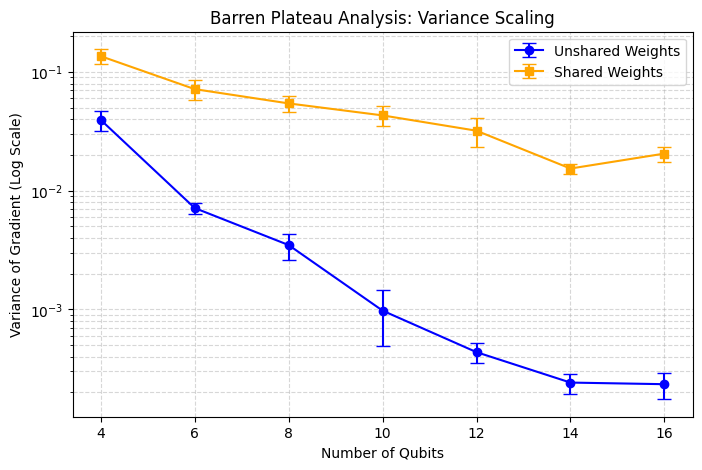

In [5]:
# --- Configuration ---
init_q = 4
final_q = 16 # Adjusted for local execution constraints
qubits = list(range(init_q, final_q + 1, 2))

num_samples = 50       
num_repetitions = 3    
conv_params = 15 
pool_params = 1
param_idx_to_track = 1 

# --- Execution ---
vars_u, vars_s = run_barren_plateau_analysis(
    qubits_list=qubits,
    num_samples=num_samples,
    num_repetitions=num_repetitions,
    conv_params=conv_params,
    pool_params=pool_params,
    param_idx_to_track=param_idx_to_track,
    device_name='lightning.qubit' # Requires PennyLane-Lightning plugin for speed
)

# --- Process Results ---
mean_u = np.mean(vars_u, axis=0)
std_u = np.std(vars_u, axis=0)

mean_s = np.mean(vars_s, axis=0)
std_s = np.std(vars_s, axis=0)

# --- Plotting ---
plt.figure(figsize=(8, 5))

plt.errorbar(
    qubits, mean_u, yerr=std_u, 
    marker='o', label='Unshared Weights', color='blue', 
    linestyle='-', capsize=5, elinewidth=1.5
)

plt.errorbar(
    qubits, mean_s, yerr=std_s, 
    marker='s', label='Shared Weights', color='orange', 
    linestyle='-', capsize=5, elinewidth=1.5
)

plt.yscale('log') 
plt.xlabel('Number of Qubits')
plt.ylabel('Variance of Gradient (Log Scale)')
plt.title(f'Barren Plateau Analysis: Variance Scaling')
plt.xticks(qubits)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# plt.savefig('data/variance_scaling.png')
plt.show()

## 5. Architecture Sanity Check & Visualization

To verify our network's hierarchical structure, we can draw the full circuit for an 8-qubit system. Here, we include an initial `AngleEmbedding` layer to simulate how classical features (like our future supply chain data) will be loaded into the circuit before being processed by the alternating Convolutional and Pooling layers.

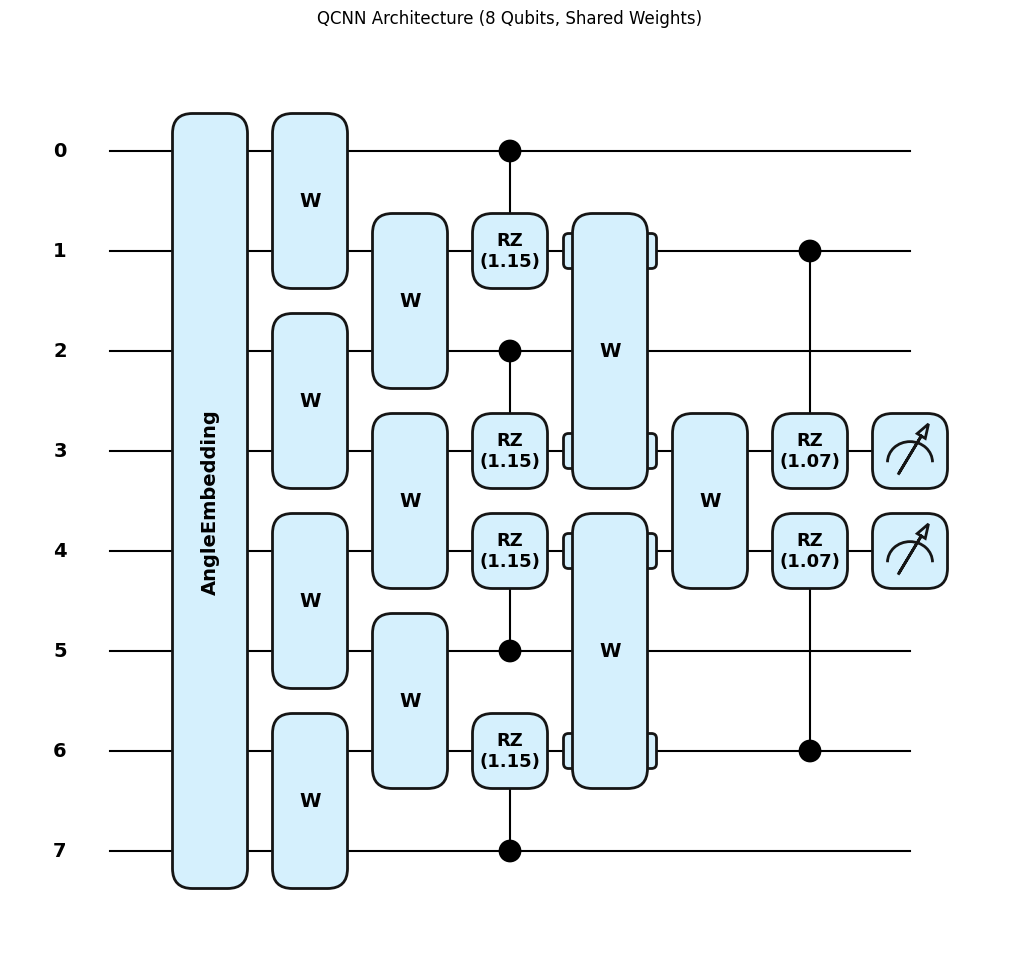

In [6]:
# --- Configuration for Drawing ---
n_qubits = 8
conv_params = 15
pool_params = 1

dev = qml.device("default.qubit", wires=n_qubits)

# Calculate the total number of parameters needed for the shared architecture
total_p = get_total_params(n_qubits, conv_params, pool_params, shared=True)

# Initialize reproducible random weights and mock input data
np.random.seed(42)
weights = np.random.uniform(0, 2 * np.pi, size=total_p, requires_grad=True)
x = np.random.uniform(0, 2 * np.pi, size=n_qubits)

@qml.qnode(dev)
def circuit_qcnn(weights, x):
    # 1. State Preparation / Data Embedding
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    
    # 2. Build the hierarchical QCNN architecture
    # We use the shared weights function to easily see the repeated structure
    final_wires = qcnn_layers_flat_shared(weights, n_qubits, conv_params, pool_params)
    
    # 3. Measurement (Expectation value on the final un-pooled wires)
    return qml.expval(qml.PauliZ(final_wires[0]) @ qml.PauliZ(final_wires[1]))

# --- Draw the Circuit ---
# We use qml.draw_mpl to generate a high-quality Matplotlib figure
fig, ax = qml.draw_mpl(circuit_qcnn, decimals=2, style='pennylane')(weights, x)

plt.title(f"QCNN Architecture ({n_qubits} Qubits, Shared Weights)", pad=20)
plt.show()